In [1]:
import math
import random

def generate_cities(n):
    return [(random.randint(0, 100), random.randint(0, 100)) for _ in range(n)]

def build_dist_matrix(cities):
    n = len(cities)
    dist_matrix = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            dx = cities[i][0] - cities[j][0]
            dy = cities[i][1] - cities[j][1]
            dist_matrix[i][j] = math.sqrt(dx**2 + dy**2)
    return dist_matrix

cities = generate_cities(10)
dist_matrix = build_dist_matrix(cities)

In [2]:
def create_initial_population(no_of_cities, size_of_population):
    population = []
    route = list(range(no_of_cities))

    for _ in range(size_of_population):
        shuffled = route[1:]
        random.shuffle(shuffled)
        population.append([0] + shuffled)
    return population

In [3]:
def total_distance(route, dist_matrix):
    total = 0
    n = len(route)
    for i in range(n):
        total += dist_matrix[route[i]][route[(i+1) % n]]
    return total

def fitness(route, dist_matrix):
    return 1 / total_distance(route, dist_matrix)

In [4]:
def get_parents(population, dist_matrix):
    random.shuffle(population)
    parents = []
    mid = len(population) // 2
    for i in range(mid):
        if fitness(population[i], dist_matrix) > fitness(population[i + mid], dist_matrix):
            parents.append(population[i])
        else:
            parents.append(population[i + mid])
    return parents

In [5]:
def ox(primary, secondary):
    start = random.randint(0, len(primary) - 1)
    end = random.randint(start, len(primary))
    child = primary[start:end]
    for i in secondary:
        if i not in child:
            child.append(i)
    return child

def apply_crossover(population):
    random.shuffle(population)
    children = []
    mid = len(population) // 2
    for i in range(mid):
        p1, p2 = population[i], population[i + mid]
        child1 = ox(p1, p2)
        child2 = ox(p2, p1)
        children.extend([child1, child2])
    return children

In [6]:
def apply_mutation(parents):
    
    for route in parents:
        if random.randint(1, 100) < 5:
            index1 = random.randint(1, len(route) - 1)
            index2 = random.randint(1, len(route) - 1)
            route[index1], route[index2] = route[index2], route[index1]
            
    return parents

In [7]:
def generate_new_population(population, dist_matrix):
    population_size = len(population)
    parents = get_parents(population, dist_matrix)
    offspring = apply_crossover(parents)
    offspring = apply_mutation(offspring)
    
    while len(offspring) < population_size:
        offspring.append(random.choice(population))
    
    return offspring[:population_size]

In [8]:
def get_best_route(population, dist_matrix):
    best = population[0]
    for route in population:
        if total_distance(route, dist_matrix) < total_distance(best, dist_matrix):
            best = route
    return best

def run_ga(no_of_cities, population_size, generations):
    cities = generate_cities(no_of_cities)
    dist_matrix = build_dist_matrix(cities)
    population = create_initial_population(no_of_cities, population_size)
    
    best_route = get_best_route(population, dist_matrix)
    
    for gen in range(generations):
        population = generate_new_population(population, dist_matrix)
        
        current_best = get_best_route(population, dist_matrix)
        if total_distance(current_best, dist_matrix) < total_distance(best_route, dist_matrix):
            best_route = current_best
        
        print(f"Generation {gen + 1} | Best Distance: {total_distance(best_route, dist_matrix):.2f}")
    
    return best_route, cities, dist_matrix

In [9]:
import matplotlib.pyplot as plt

def visualize_route(route, cities, dist_matrix):
    x = [cities[i][0] for i in route] + [cities[route[0]][0]]
    y = [cities[i][1] for i in route] + [cities[route[0]][1]]

    plt.figure(figsize=(8, 6))
    plt.plot(x, y, 'b-o')                              # route lines + city dots
    for i, city in enumerate(cities):
        plt.annotate(str(i), city, fontsize=10)         # label each city
    plt.title(f"Best Route | Total Distance: {total_distance(route, dist_matrix):.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

Generation 1 | Best Distance: 864.99
Generation 2 | Best Distance: 832.47
Generation 3 | Best Distance: 832.47
Generation 4 | Best Distance: 787.97
Generation 5 | Best Distance: 774.51
Generation 6 | Best Distance: 773.95
Generation 7 | Best Distance: 773.95
Generation 8 | Best Distance: 762.49
Generation 9 | Best Distance: 762.49
Generation 10 | Best Distance: 690.91
Generation 11 | Best Distance: 690.91
Generation 12 | Best Distance: 690.91
Generation 13 | Best Distance: 690.91
Generation 14 | Best Distance: 690.91
Generation 15 | Best Distance: 690.91
Generation 16 | Best Distance: 690.91
Generation 17 | Best Distance: 690.91
Generation 18 | Best Distance: 690.91
Generation 19 | Best Distance: 690.91
Generation 20 | Best Distance: 690.91
Generation 21 | Best Distance: 635.30
Generation 22 | Best Distance: 635.30
Generation 23 | Best Distance: 635.30
Generation 24 | Best Distance: 635.30
Generation 25 | Best Distance: 635.30
Generation 26 | Best Distance: 635.30
Generation 27 | Best 

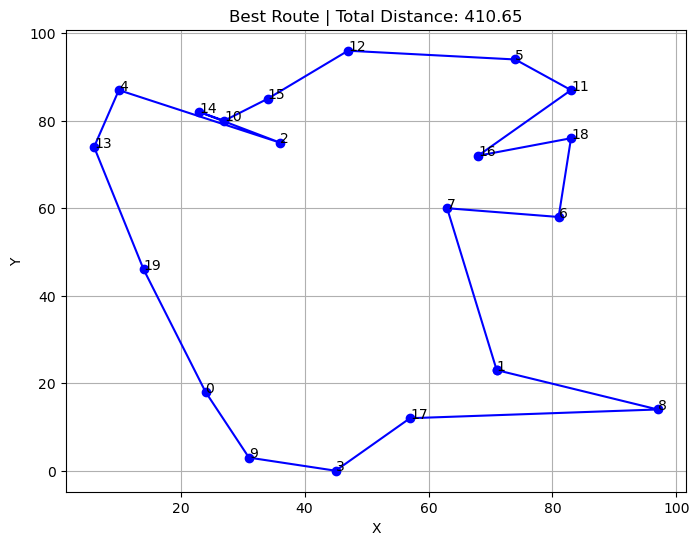

In [10]:
best_route, cities, dist_matrix = run_ga(20, 100, 500)
visualize_route(best_route, cities, dist_matrix)